# MTY4-NB02: Data Visualization
by Sergio Eraso

## Contents
0. Introduction
1. Quick Figures
2. Advanced Figures
3. Animations

## 0. Introduction

In scientific computing and data analysis, understanding the structure and patterns in your data is just as important as processing it. Raw numbers alone can be overwhelming or misleading—visualization helps turn those numbers into insight. Matplotlib is one of the most widely used libraries for data visualization in Python. It provides powerful tools to create a wide range of static, animated, and interactive plots.

Whenever you are learning something new in programming, you should always have the documentation on hand:

- [Numpy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [Matplotlib quickstart](https://matplotlib.org/stable/users/explain/quick_start.html)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

Matplotlib offers two ways to create figures:
1. **PyPlot Interface:** a quick approach similar to MATLAB where the state of a figure is preserved through various function calls
2. **Object-Oriented Interface:** a traditional OOP approach where objects are modified through their methods

While we introduce the PyPlot interface, we encourage you to use method 2 for serious projects as it is simply more powerful.

Here is a good [article](https://matplotlib.org/matplotblog/posts/pyplot-vs-object-oriented-interface/) on the differences between the two methods if you are curious.

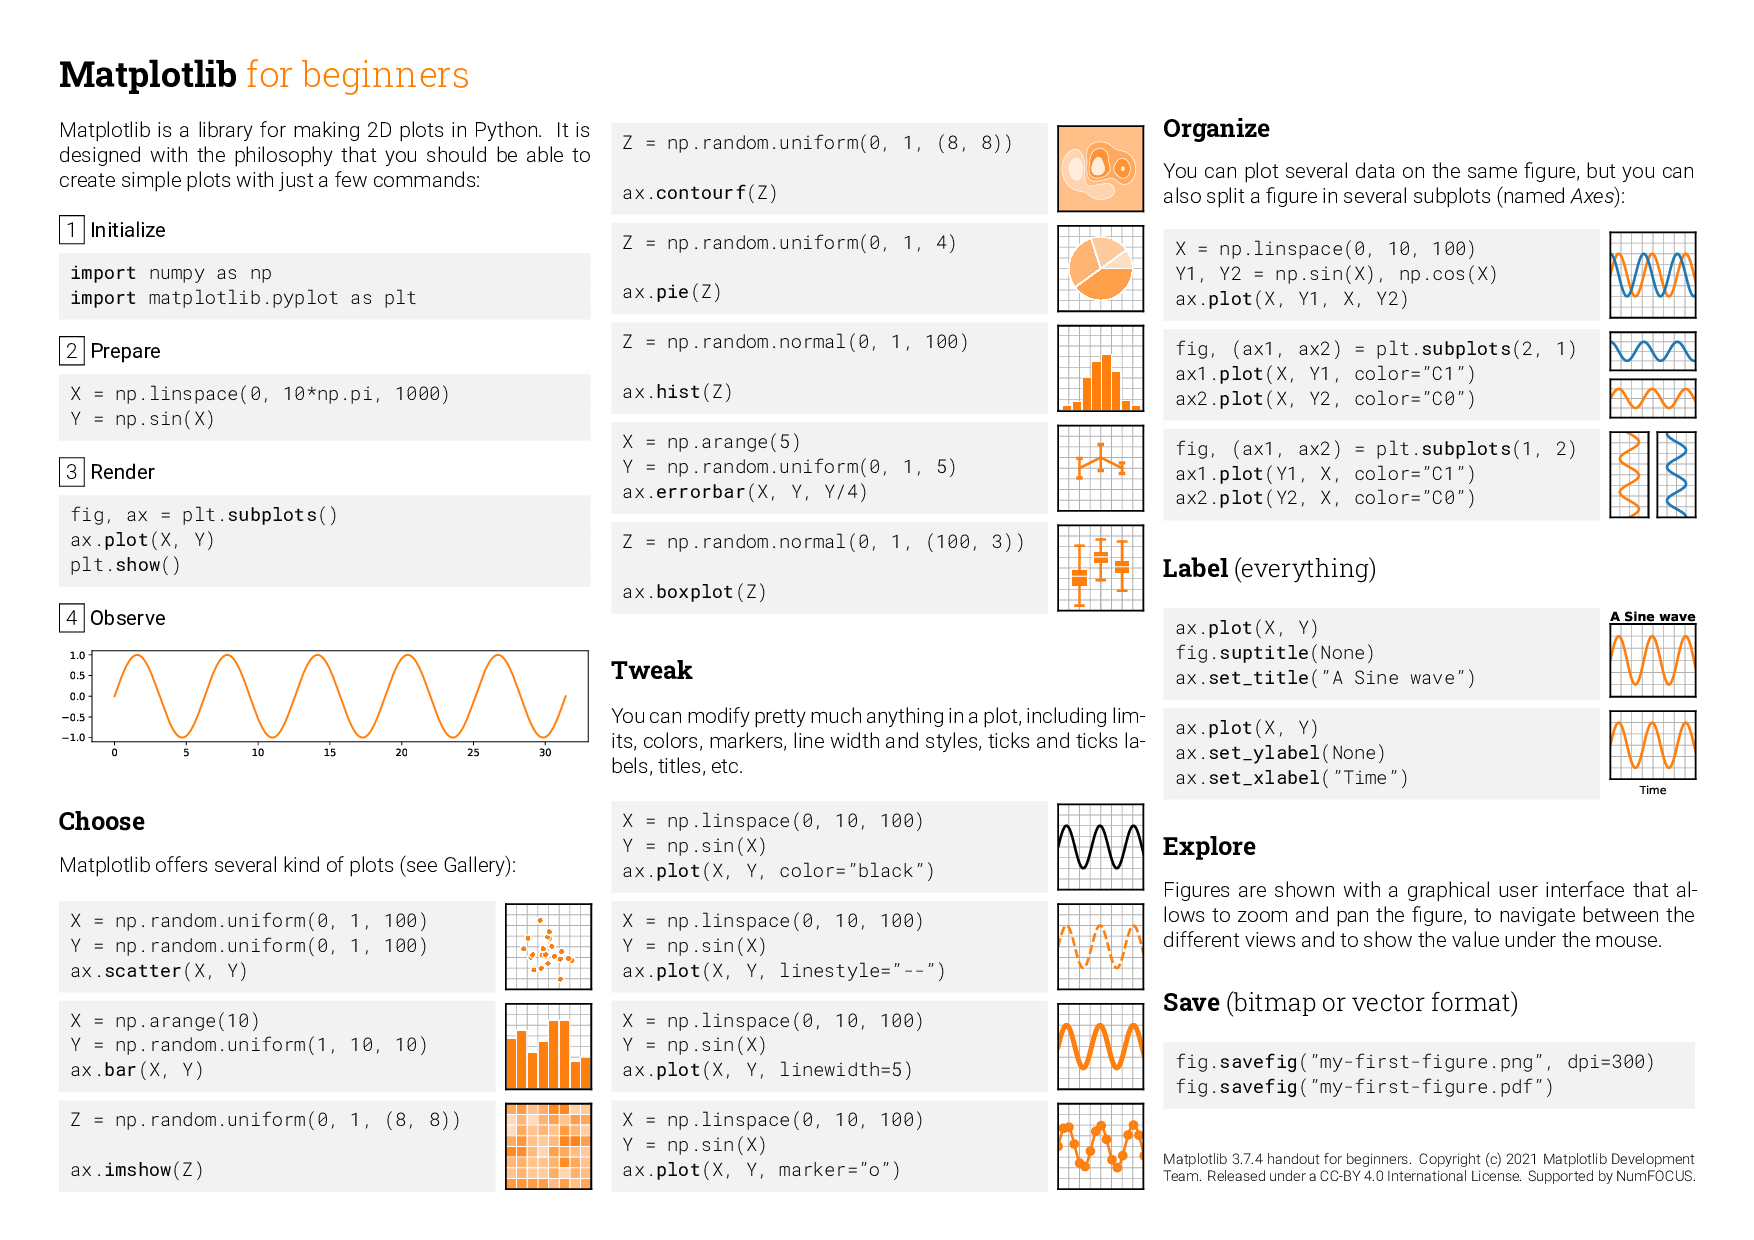

## 1. Quick Figures (PyPlot)

Let's create our first figure of the linear function using the PyPlot interface $$y = bx + a$$ We must first create the data we are going to plot. Let's use Numpy for this!

In [ ]:
a = 3   # y-intercept   
b = 2   # slope
x_values = np.linspace(0, 1, 50)  # 50 points from 0 to 1
y_values = b*x_values + a           # use numpy operations to easily calculate y values

Now, creating a plot only takes one line of code!

In [ ]:
plt.plot(x_values, y_values)  # plot the line

We don't want to create such ugly plots though. Every plot should come with at least a title and axes labels! Let's add some color too!

In [ ]:
plt.plot(x_values, y_values, color="red")   # plot the line in red
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Function: y = bx + a")
plt.grid(alpha=0.5)     # alpha controls the transparency of the grid

#### *Exercise: Cubic Function*

Plot the function $f(x) = x^3 + 1$ from $x\in[-1,1]$. Make sure your plot has:
1. a title
2. axes labels
3. a color
4. a grid

We can also visualize 2D arrays, such as an image or the elements of a matrix using `imshow`.

In [ ]:
lattice = np.random.randint(0,10, size=(100,100))
plt.imshow(lattice, cmap="viridis")

As always, you should label your axes. For images, it is also usually useful to include a colorbar.

In [ ]:
plt.imshow(lattice, cmap="viridis")
# include a colorbar
plt.colorbar(label="Value")
plt.title("Lattice")
plt.xlabel("column")
plt.ylabel("row")

## 2. Advanced Figures (OOP)

While the above way of creating plots is very quick, we eventually want to have full control over our figures. We now present a slightly more cumbersome way of creating figures, but it will allow us to eventually have animations. The most obvious difference is that we must now **initialize** our figure and axes using the `subplots` function.

In [ ]:
fig, ax = plt.subplots(dpi=150)  # create a figure and axes with a specific resolution

This command accomplishes two things:

1. Creates a Figure (`fig`)
   
    The Figure is the overall container for your entire plot (or collection of plots). Think of it as the blank canvas or page that will hold one or more sub-plots, titles, legends, and other decorations.

2. Creates one (or more) Axes (`ax`)
   
    The Axes is the actual plotting area — the region where data appear as lines, markers, bars, etc. It handles the x- and y-axis, ticks, labels, and the plot itself.

We now call functions directly on the axes object `ax` to plot our data.

In [ ]:
ax.plot(x_values, y_values, color="red")  # notice that we directly use the axes object to plot, rather than the pyplot interface
ax.set_xlabel("x")      # we can set labels and titles on the axes object in an object-oriented way
ax.set_ylabel("y")
ax.set_title("Linear Function: y = bx + a")
ax.grid(alpha=0.5)     # alpha controls the transparency of the grid
display(fig)

We can also have multiple sets of data on one plot. Let's generate some new data $$y_1 = \sin(t), \qquad y_2 = \cos(t)$$ for times $t\in[-2\pi, 2\pi]$.

In [ ]:
ts = np.linspace(-2*np.pi,2*np.pi,100)          # create array of times
y1 = np.sin(ts)      # evaluate sin at each time
y2 = np.cos(ts)    # evaluate cos at each time

And let's include a legend this time to make the plot more readable.

In [ ]:
fig, ax = plt.subplots(dpi=150)
# simply call `plot` twice to plot both sets of data
ax.plot(ts, y1, color="red", label="sin(t)")
ax.plot(ts, y2, color="blue", label="cos(t)")
ax.set_title("Waves")
ax.set_xlabel("t")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.5)     # add grid
ax.legend()        # add legend with default options

#### *Exercise: Graphing Exp and Log*

Create a figure that plots the exponential function and its inverse $$f(x) = e^{x/2}, \qquad f^{-1}(x) = 2\log(x)$$ on the same set of axes for $x\in[-4,4]$. Make sure your plot has:
1. a title
2. axes labels
3. colors
4. a grid
5. a legend

*(Hint: be careful where you evaluate log)*

In [ ]:
# ---------Exercise-----------
# your code here

PLotting 2D data follows a similar procedure. Notice that the colorbar now belongs to the figure and that we must now pass `im` to the `colorbar` function.

In [ ]:
lattice = np.random.randint(0,11, size=(32,32))     # random 2D array of integers from 0 to 10

fig, ax = plt.subplots(dpi=150)                     # increase the resolution
im = ax.imshow(lattice, cmap="Grays")               # plot the latice using the colors "Grays"  
fig.colorbar(mappable=im, ax=ax, label="Value")     # add a colorbar to the figure
ax.set_title("Lattice")
ax.set_xlabel("column")
ax.set_ylabel("row")

Matplotlib has many colormaps to choose from

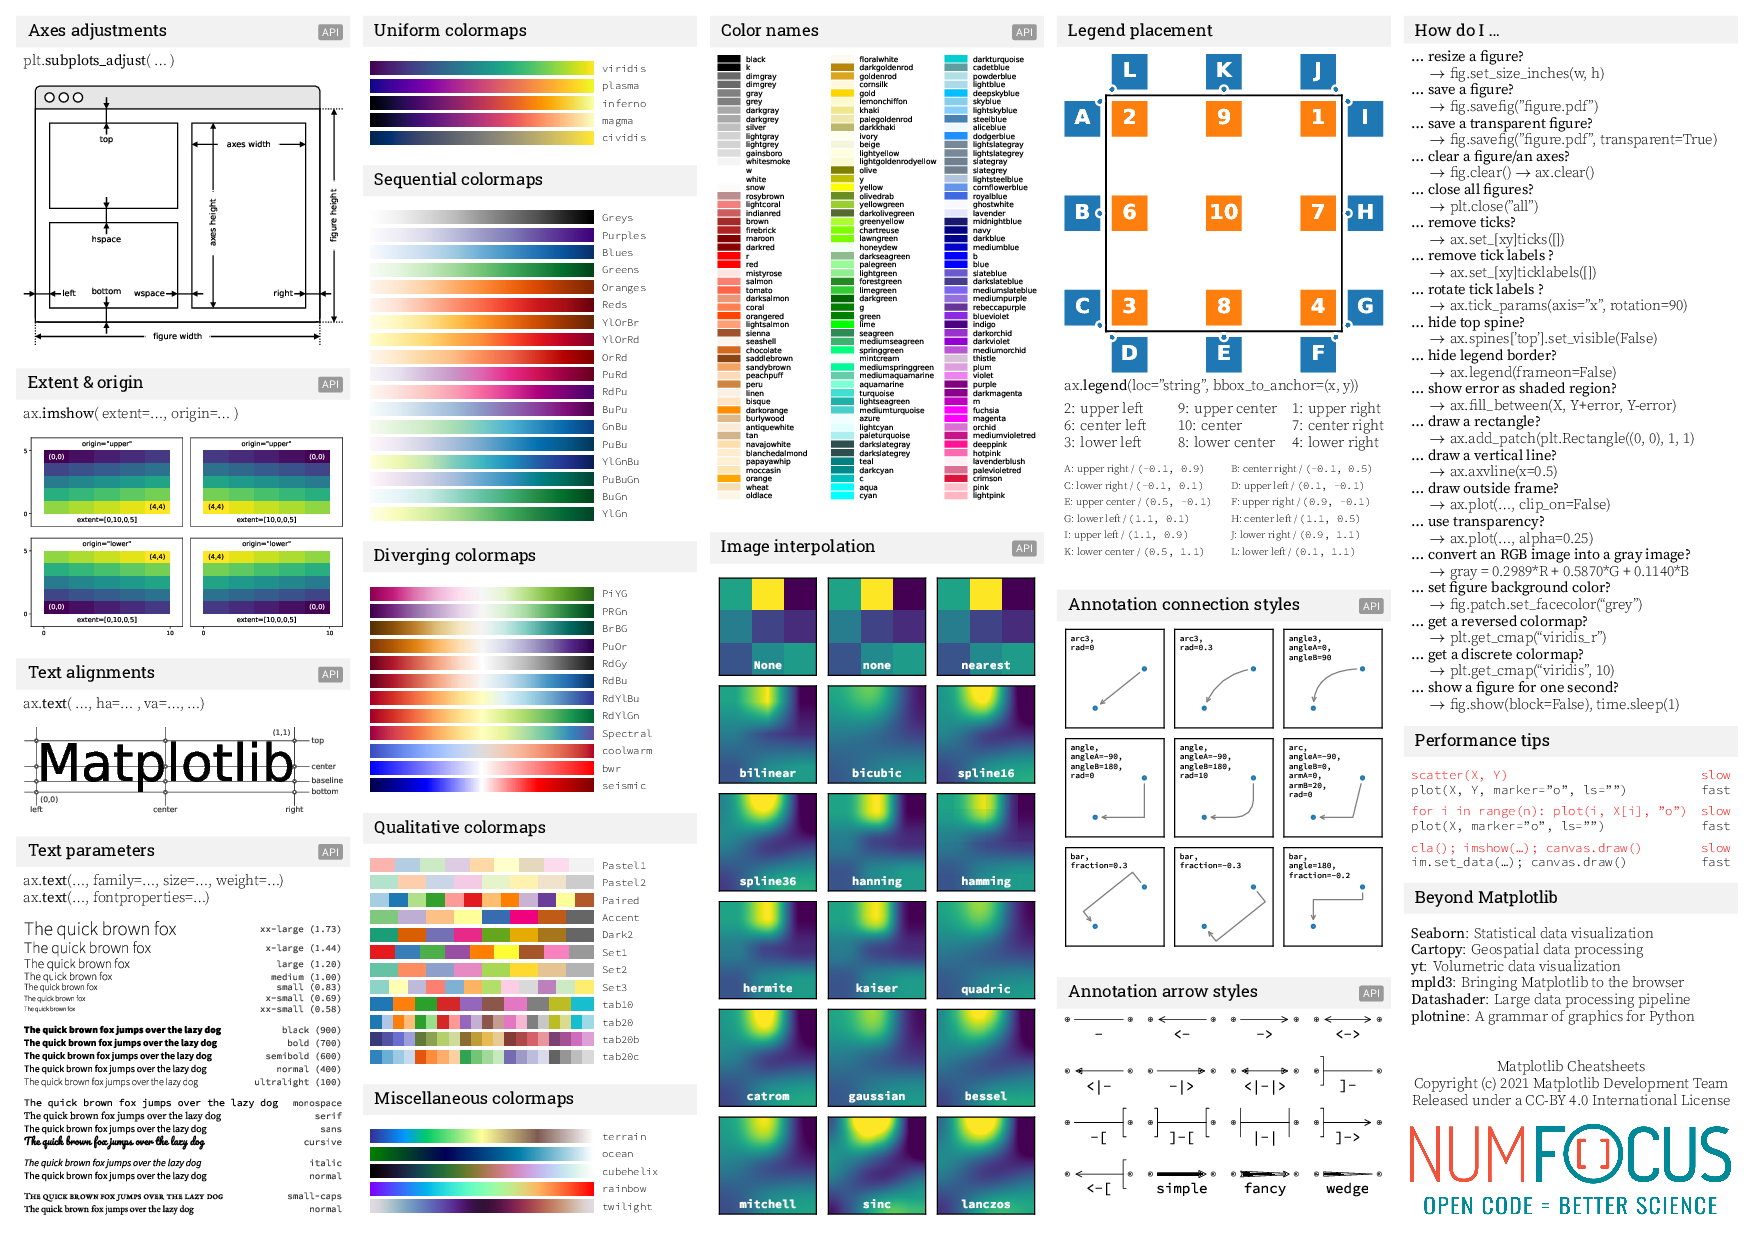

## 3. Animations

Visualizing how data evolves over time can be just as important as seeing static snapshots. We'll need to import a couple of things to get our notebook ready for animations.

In [ ]:
from matplotlib import animation, rcParams
# set up the notebook to display animations
from IPython.display import HTML        # this is used to display the animation in the notebook
import imageio_ffmpeg                   # this is used to save the animation as a video file
rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

To create an animation, you just need three things:
1. A figure and axis using a `subplots` call
2. An update function
3. A `FuncAnimation` call

We already know how to do step 1 -- the only difference is that we don't want to include any data in this initialization. Let's animate the wave plot we created earlier. Also note that we save the two plots as `line1` and `line2`.

In [ ]:
# We now create the elements of our plot that will be updated during the animation 
# as well as the other elements of the plot (eg. title, legend, etc.).
fig, ax = plt.subplots(dpi=150)  # create a figure and axis with high resolution
line1, = ax.plot([], [], color="red", lw=2)     # we create empty lines that will be updated during the animation
line2, = ax.plot([], [], color="blue", lw=2)    # lw stands for line width

# decorate the plot
ax.set_xlim(-2*np.pi,2*np.pi)       # set the x limits of the plot to avoid rescaling during the animation
ax.set_ylim(-1.5, 1.5)              # similarly for y limits
ax.set_title("Waves")
ax.set_xlabel("t")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.5)     # add grid
ax.legend(["sin(t)", "cos(t)"])

Since our data was already generated in the previous section, our update function will simply take this data and display it up to the desired time. The update function must return the elements we want to update. In this case, we are manipulating `line1` and `line2`.

In [ ]:
# our update function
def drawframe(frame_number):
    line1.set_data(ts[:frame_number], y1[:frame_number])    # include only the data up to the current frame
    # this way, the line will grow as the animation progresses
    # we use the same ts array for both lines, but we could use different arrays if needed
    line2.set_data(ts[:frame_number], y2[:frame_number])
    
    # return the lines to be updated
    return line1, line2

Finally, we create our animation using the `FuncAnimation` function.

In [ ]:
num_frames = len(ts)
anim = animation.FuncAnimation(fig,                 # the figure to animate
                               func=drawframe,      # the function to call for each frame
                               frames=num_frames,   # the total number of frames
                               interval=20,         # time between frames in milliseconds
                               blit=True            # blit=True means that only the parts of the plot that change will be redrawn, which is more efficient
                               )

And we display it in the notebook using `HTML`!

In [ ]:
HTML(anim.to_jshtml())

That took a while! Let's save our animation to our computer.

In [ ]:
anim.save("waves.mp4", writer="ffmpeg", fps=30)  # save the animation as a video file